In [30]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
pg = sns.load_dataset('penguins')
tips = sns.load_dataset('tips')

In [21]:
# penguins 데이터 불러와서 ->시각화 및 train/ test 분할 해보기
pg

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [22]:
pg.groupby('species').count()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
species,,,,,,
Adelie,152,151,151,151,151,146
Chinstrap,68,68,68,68,68,68
Gentoo,124,123,123,123,123,119


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

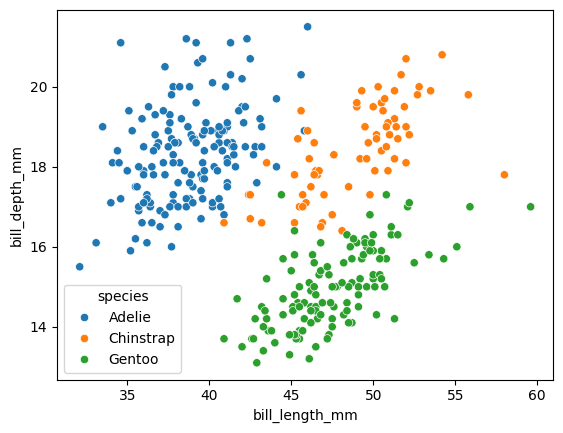

In [23]:
sns.scatterplot(pg, x= 'bill_length_mm', y= 'bill_depth_mm', hue= 'species')

In [24]:
X = pg.drop('species',axis=1)
Y = pg['species']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2 ,random_state=42)

In [27]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(275, 6) (69, 6)
species
Adelie       0.436364
Gentoo       0.374545
Chinstrap    0.189091
Name: proportion, dtype: float64


In [ ]:
# X_train: 275개 샘플, 6개의 특성(feature), X_test: 69개 샘플, 6개의 특성(feature)
# specie가 Adel 43% > Gen 37% > Chin 18% 

In [ ]:
# tips 데이터 불러와서 -> 팁 급액 분석 , train/test 셋 분류 및 분류 시각화

In [28]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: >

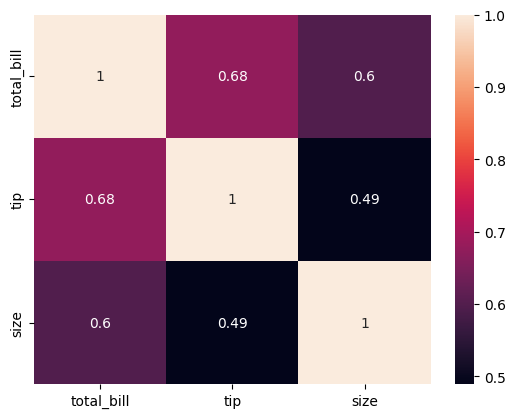

In [39]:
corr =tips.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True)

<Axes: xlabel='sex', ylabel='tip'>

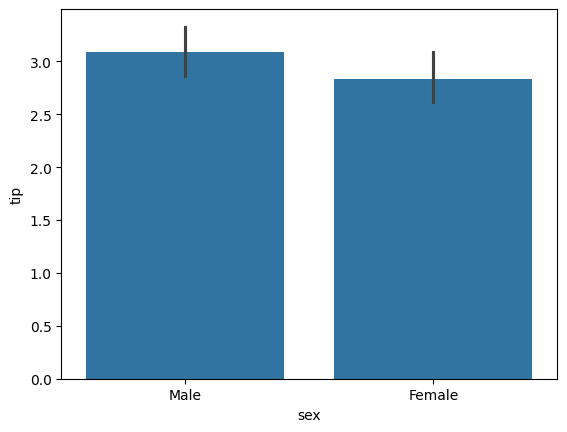

In [42]:
sns.barplot(tips, x='sex',y='tip')

<Axes: xlabel='smoker', ylabel='tip'>

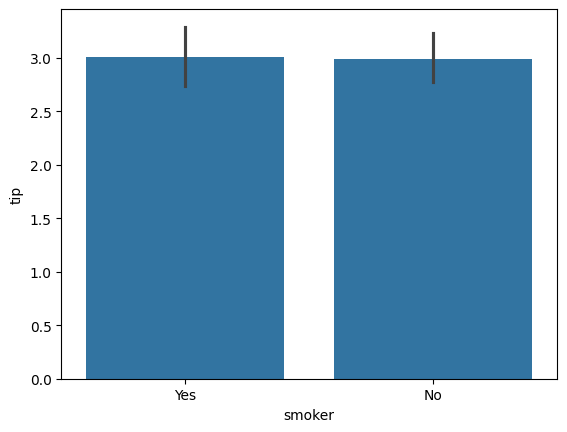

In [44]:
sns.barplot(tips, x='smoker',y='tip')

<Axes: xlabel='day', ylabel='tip'>

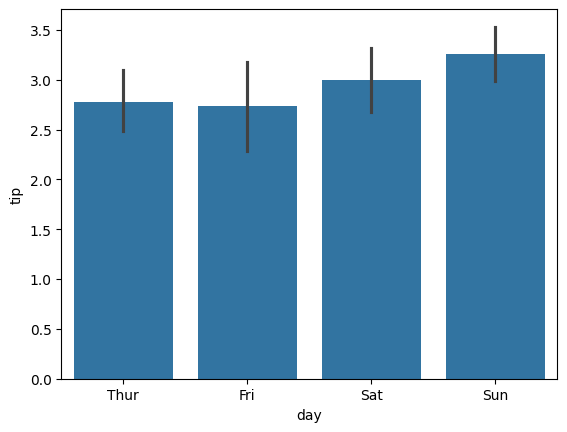

In [43]:
sns.barplot(tips, x='day',y='tip')

<Axes: xlabel='time', ylabel='tip'>

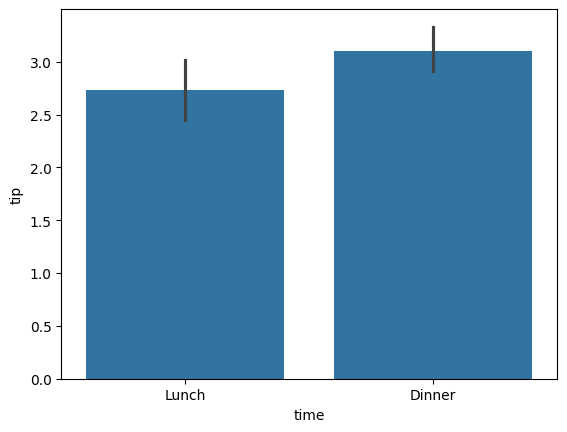

In [45]:
sns.barplot(tips, x='time',y='tip')

<Axes: xlabel='size', ylabel='tip'>

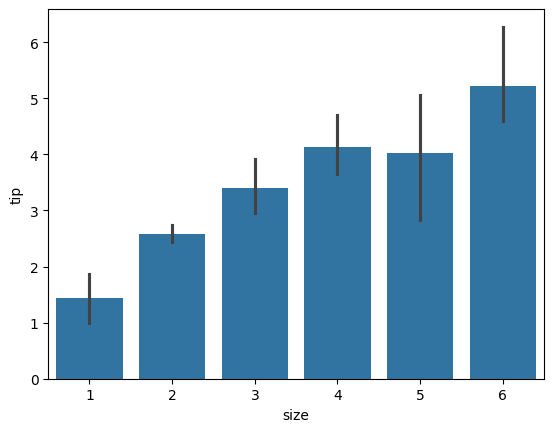

In [46]:
sns.barplot(tips, x='size',y='tip')

In [ ]:
# tip 금액은  
# 수치형 데이터중에서 total_bill 과 가장 큰 양의 상관 관계(0.68)을 가짐
# 성별은 남성에서 약간 더 높은 차이를 보임
# smoke 여부는 별 차이 없음
# 요일중에서는 일요일>토요일>목요일>금요일 순으로 높은 경향을 보임
# 점심보다 저녁에서 팁이 더 높은 경향을 보임
# 인원이 높을수록 팁이 높아지는 경향으로 보이지만 5명보다 4명이 올때 약간 더 높았음

In [47]:
X = tips.drop('tip',axis=1)
Y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2 ,random_state=42)

In [49]:
y_train.value_counts(sort= True)

tip
2.00    24
3.00    21
2.50    10
4.00     9
1.50     7
        ..
2.02     1
2.30     1
2.54     1
3.08     1
3.55     1
Name: count, Length: 103, dtype: int64

<Axes: xlabel='tip', ylabel='Density'>

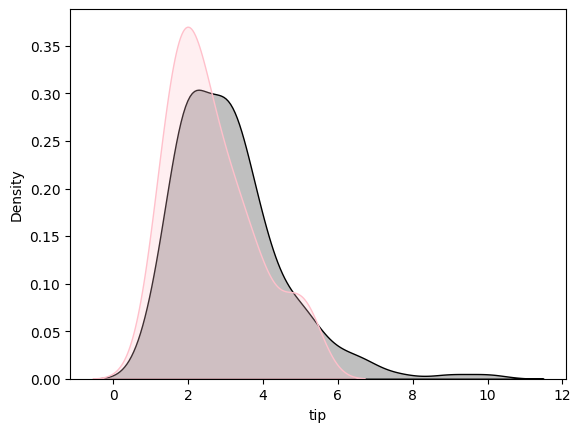

In [55]:
sns.kdeplot(y_train, label='Train', fill=True, color = 'black')
sns.kdeplot(y_test, label='Test', fill=True, color = 'pink')